In [75]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.stats import kstest

In [76]:
names = ["Nikita", "Damir"]
surnames = ["Glazunov", "Abuzarov"]

def eval_k_j():
    n1, n2 = map(ord, [name[0] for name in names])
    s1, s2 = map(ord, [surname[0] for surname in surnames])
    sum1 = n1 + n2 - 2 * (ord('A') - 1)
    sum2 = s1 + s2 - 2 * (ord('A') - 1)

    return sum1 // 2, sum2 // 2

In [77]:
dists = {
    'gamma': (stats.gamma, {'a': 2, 'scale': 1/3}),
    'norm': (stats.norm, {'loc': 0, 'scale': 4})
}

In [78]:
def gen_distribution(func, theta, size, seed=4071505):
    return func.rvs(**theta, size=size, random_state=seed)

def theoretical_moments(func, theta):
    mean, var, kurt = func.stats(**theta, moments='mvk')
    mu4 = (kurt + 3.0) * var ** 2

    return mean, var, mu4

In [79]:
def plot_hist_with_pdf(x, pdf, title, bins=60):
    plt.figure(figsize=(12, 8))

    plt.hist(x, bins=bins, density=True, alpha=0.7,
             color="steelblue", edgecolor="black")
    
    xs = np.linspace(np.min(x), np.max(x), 500)
    
    plt.plot(xs, pdf(xs), "r-", lw=2)
    plt.title(title)
    plt.xlabel("значение")
    plt.ylabel("плотность")

    plt.show()

In [ ]:
def run_experiment(dist_name, n=200, N=5000, seed=4071505):
    if dist_name not in dists.keys():
        raise ValueError(f"no such distribution type: {dist_name}")
    
    func, theta = dists[dist_name]
    k, j = eval_k_j()

    theor_mean, theor_var, theor_mu4 = theoretical_moments(func, theta)
    theor_median = float(func.ppf(0.5, **theta))
    theor_f_median = float(func.pdf(theor_median, **theta))

    X = gen_distribution(func=func, theta=theta, size=(N, n), seed=seed)

    means = X.mean(axis=1)
    varss = X.var(axis=1, ddof=0)
    medians = np.quantile(X, 0.5, axis=1)

    U_mean = np.sqrt(n) * (means - theor_mean) / np.sqrt(theor_var)
    
    U_var = np.sqrt(n) * (varss - theor_var) / np.sqrt(theor_mu4 - theor_var ** 2)

    U_median = 2.0 * np.sqrt(n) * theor_f_median * (medians - theor_median)

    sorted_X = np.sort(X, axis=1)
    T1 = n * func.cdf(sorted_X[:, k - 1], **theta)
    T2 = n * (1.0 - func.cdf(sorted_X[:, n - j], **theta))

    return {
        'k': k, 'j': j,
        'U_mean': U_mean, 'U_var': U_var, 'U_median': U_median,
        'T1': T1, 'T2': T2
    }

In [81]:
def report_and_plot(res):
    k, j = res['k'], res['j']
    
    norm_std = stats.norm(loc=0, scale=1)
    gamma_k = stats.gamma(a=k, scale=1)
    gamma_j = stats.gamma(a=j, scale=1)

    checks = [
        ("U_mean", res['U_mean'], norm_std.pdf),
        ("U_var", res['U_var'], norm_std.pdf),
        ("U_median", res['U_median'], norm_std.pdf),
        (f"T1 = nF(X_({k}))", res['T1'], gamma_k.pdf),
        (f"T2 = n(1-F(X_(n+1-{j})))", res['T2'], gamma_j.pdf),
    ]

    for name, arr, pdf in checks:
        plot_hist_with_pdf(arr, pdf, f"{name}")

(5000,)


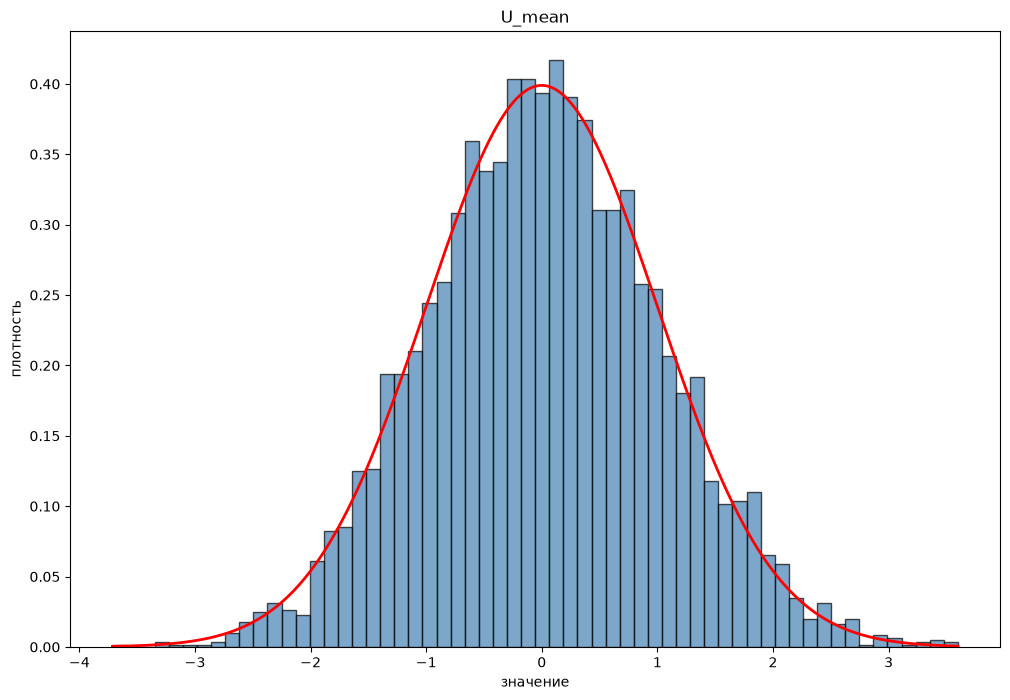

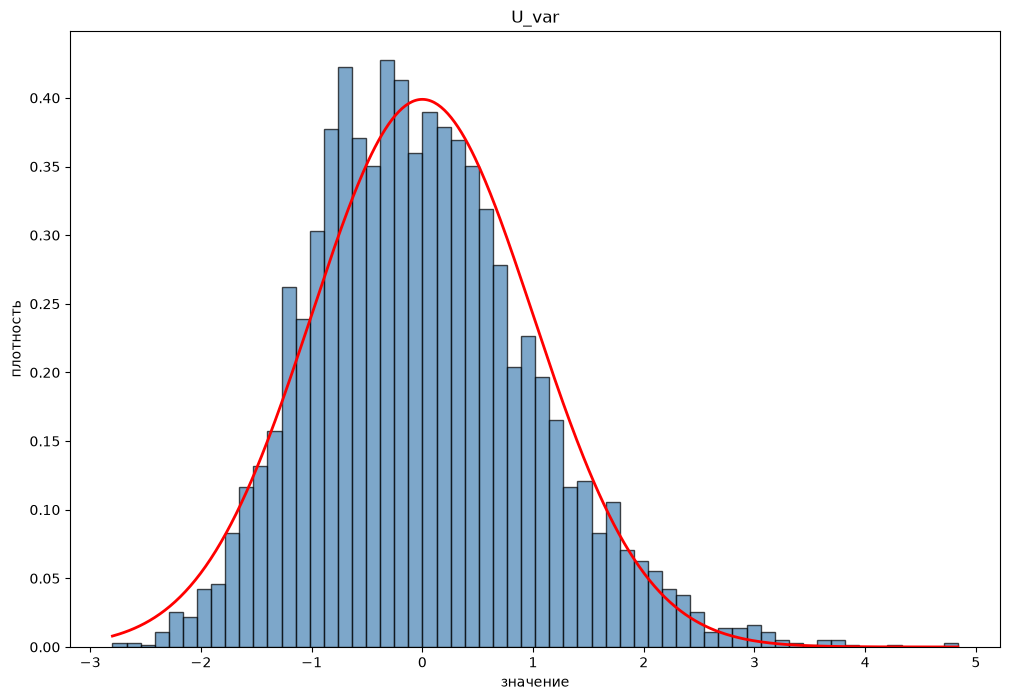

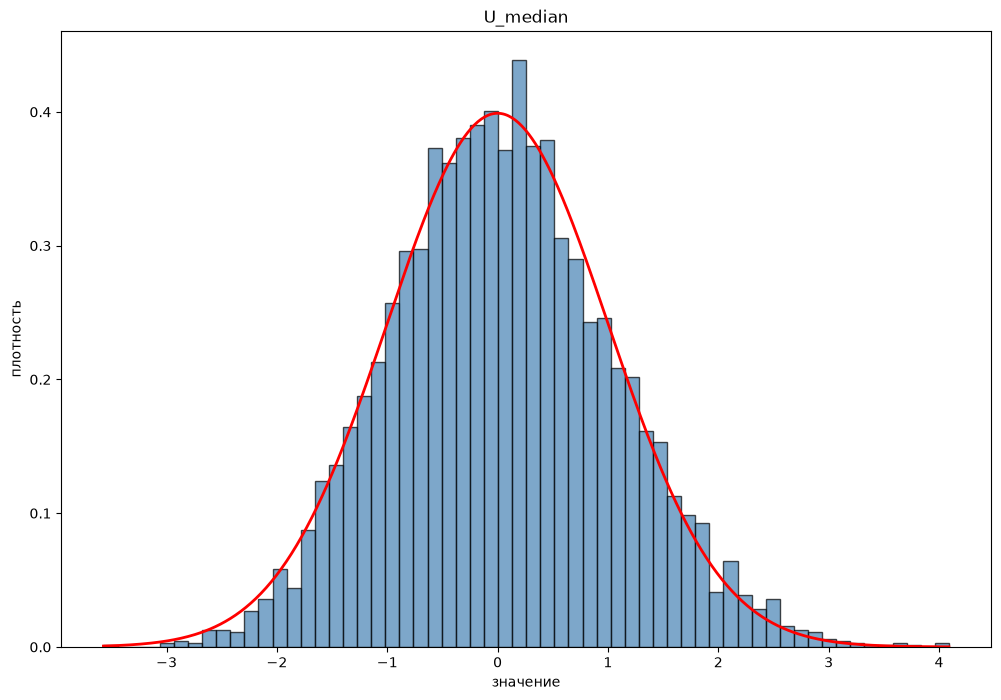

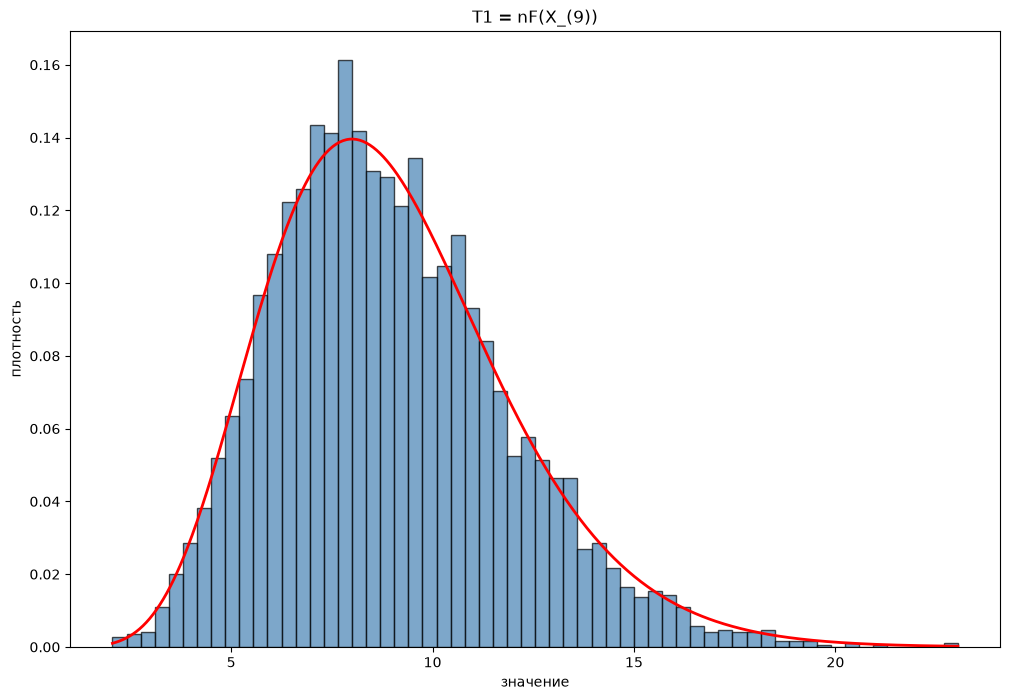

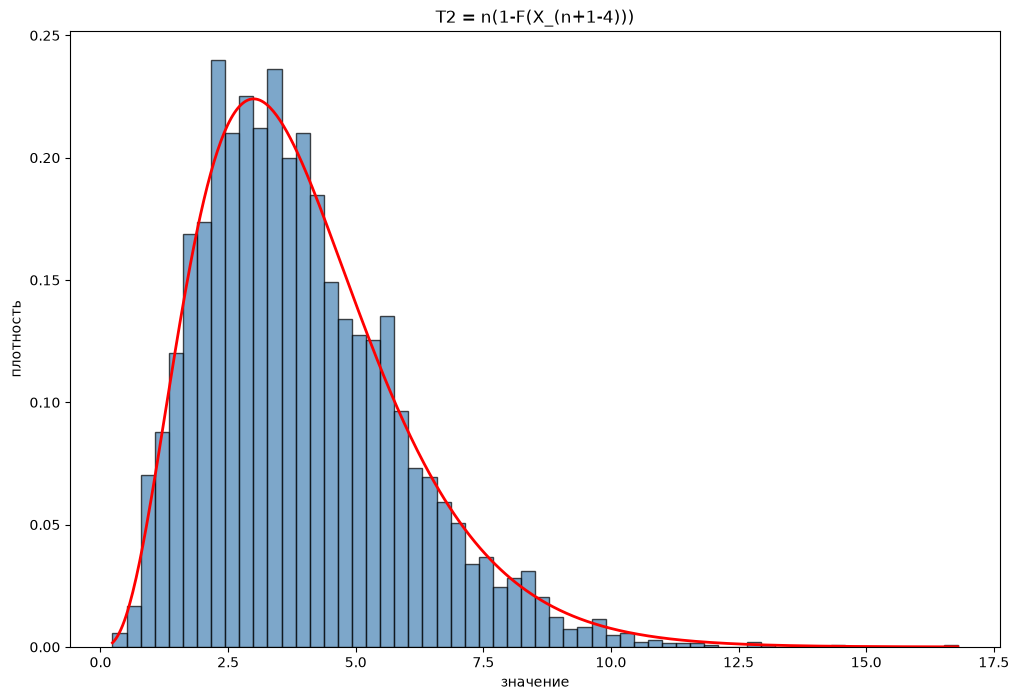

In [82]:
res_gamma = run_experiment('gamma', n=200, N=5000)
report_and_plot(res_gamma)